# Kaggle Mushrooms Dataset
Source: https://www.kaggle.com/datasets/dariobaumberger/combined-kaggle-mushrooms-dataset/data

---

## Libraries & Packages

In [62]:
# path for photo inventory
from pathlib import Path

# for opening images
from PIL import Image, UnidentifiedImageError
import re

# plots
import math
import matplotlib.pyplot as plt

# core 
import numpy as np
import pandas as pd

---

## Project Paths and Settings
- parent folder
- image extension
- random seed for later
- any global assumptions

In [55]:
# relative path and image extension
image_folder = Path(r"..\\GroupProject\\images")
image_extension = ".webp" # all images are .webp
SEED = 67

In [56]:
# check path for `image` folder to load nested folder structure
print(image_folder.resolve())
print(image_folder.exists())

D:\academic\UCF\2026_summer\Data Mining 2\GroupProject\images
True


---

# EDA
- Learn structure of image set
- Pre-processing decisions
- Main purpose is to lead into PyTorch ImageFolder setup to flow into train/test splits -> feature extraction -> baseline model -> other models -> comparison

### Table:
- folder
- possible genus
- species label
- image number within folder
- width, height, aspect_ratio
- valid_image (means PIL can open/read image size)

In [ ]:
rows = []

for class_dir in sorted(image_folder.iterdir()):
    if not class_dir.is_dir():
        continue

    folder = class_dir.name
    genus, species = folder.split(" ", 1)  # assumes folder format: "Genus species"

    for img_path in sorted(class_dir.glob(f"*{image_extension}")):
        img_number = int(img_path.stem.rsplit("_", 1)[1])  # assumes filename ends with "_i"

        try:
            with Image.open(img_path) as img:
                width, height = img.size

            valid_image = True
            aspect_ratio = width / height

        # invalid image is defined as not being able to pull this metadata
        except (UnidentifiedImageError, OSError):
            width = None
            height = None
            aspect_ratio = None
            valid_image = False

        rows.append({
            "file_path": str(img_path),
            "folder": folder,
            "genus": genus,
            "species": species,
            "img_number": img_number,
            "width": width,
            "height": height,
            "aspect_ratio": aspect_ratio,
            "valid_image": valid_image
        })

df = pd.DataFrame(rows)

print("total images:", len(df))
print("valid images:", df["valid_image"].sum())
print("invalid images:", (~df["valid_image"]).sum())

total images: 104087
valid images: 104087
invalid images: 0


In [28]:
# checking table for EDA
df = df.sort_values(["folder", "img_number"]).reset_index(drop=True)
df.head()

,file_path,folder,genus,species,img_number,width,height,aspect_ratio,valid_image
0,D:\academic\UCF\2026_summer\Data Mining 2\Grou...,Agaricus augustus,Agaricus,augustus,1,375,500,0.750000,True
1,D:\academic\UCF\2026_summer\Data Mining 2\Grou...,Agaricus augustus,Agaricus,augustus,2,333,500,0.666000,True
2,D:\academic\UCF\2026_summer\Data Mining 2\Grou...,Agaricus augustus,Agaricus,augustus,3,500,375,1.333333,True
3,D:\academic\UCF\2026_summer\Data Mining 2\Grou...,Agaricus augustus,Agaricus,augustus,4,500,375,1.333333,True
4,D:\academic\UCF\2026_summer\Data Mining 2\Grou...,Agaricus augustus,Agaricus,augustus,5,500,375,1.333333,True


### Species / Genus Distribution
This section summarizes how images are distributed across species labels and genus groups.  
The goal is to check whether the dataset is balanced enough for modeling or whether later train/test splits and evaluation should account for imbalance.

In [29]:
species_counts = (
    df.groupby(["folder", "genus", "species"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

genus_counts = (
    df.groupby("genus")
    .agg(
        species_count=("folder", "nunique"),
        image_count=("folder", "size")
    )
    .reset_index()
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# totals
print("total folder labels:", species_counts["folder"].nunique())
print("total species labels:", species_counts["species"].nunique())
print("total genus labels:", genus_counts["genus"].nunique())

# quick distribution check
print("min images per species:", species_counts["image_count"].min())
print("max images per species:", species_counts["image_count"].max())
print("median images per species:", species_counts["image_count"].median())
print("mean images per species:", species_counts["image_count"].mean())
print("mode images per species:", species_counts["image_count"].mode())

total folder labels: 169
total species labels: 164
total genus labels: 103
min images per species: 211
max images per species: 5823
median images per species: 325.0
mean images per species: 615.8994082840237
mode images per species: 0    319
Name: image_count, dtype: int64


In [30]:
# species level

# which species have most images
display(species_counts.head(10))

# which species have least images
species_counts.sort_values("image_count", ascending=True).head(5)

,folder,genus,species,image_count
0,Xanthoria parietina,Xanthoria,parietina,5823
1,Fomes fomentarius,Fomes,fomentarius,5247
2,Fomitopsis pinicola,Fomitopsis,pinicola,5090
3,Amanita muscaria,Amanita,muscaria,4577
4,Parmelia sulcata,Parmelia,sulcata,2652
5,Laetiporus sulphureus,Laetiporus,sulphureus,2590
6,Hypogymnia physodes,Hypogymnia,physodes,2153
7,Cerioporus squamosus,Cerioporus,squamosus,2100
8,Leccinum scabrum,Leccinum,scabrum,1693
9,Coprinus comatus,Coprinus,comatus,1615


,folder,genus,species,image_count
168,Psilocybe caerulescens,Psilocybe,caerulescens,211
167,Panaeolus papilionaceus,Panaeolus,papilionaceus,220
166,Volvopluteus gloiocephalus,Volvopluteus,gloiocephalus,231
165,Cryptoporus volvatus,Cryptoporus,volvatus,232
164,Galerina marginata,Galerina,marginata,234


In [31]:
# genus level

# which genus have most species
display(genus_counts.sort_values("species_count", ascending=False).head(5))

# which genus have most images
genus_counts.sort_values("image_count", ascending=False).head(15)

,genus,species_count,image_count
0,Amanita,12,8221
17,Psilocybe,6,1519
14,Suillus,5,1905
12,Trametes,5,2009
7,Boletus,4,2343


,genus,species_count,image_count
0,Amanita,12,8221
1,Fomitopsis,3,6944
2,Xanthoria,1,5823
3,Fomes,1,5247
4,Leccinum,4,3139
5,Parmelia,1,2652
6,Laetiporus,1,2590
7,Boletus,4,2343
8,Gyromitra,3,2245
9,Evernia,2,2170


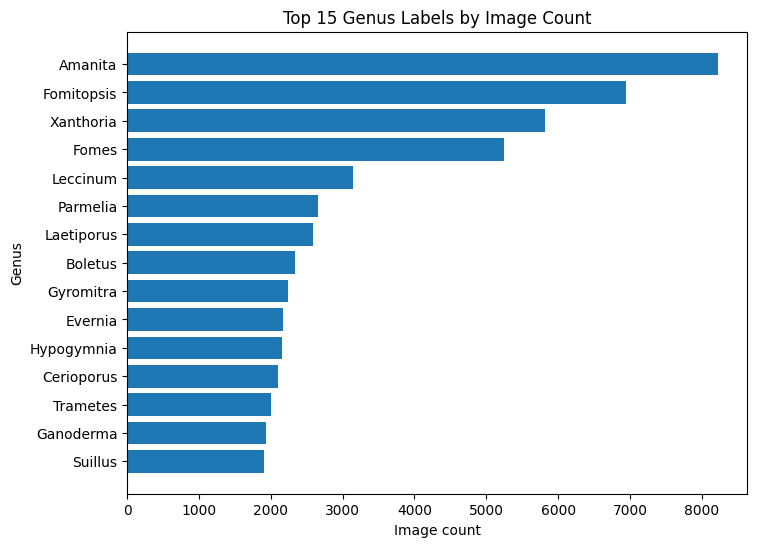

In [32]:
top_genus = genus_counts.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_genus["genus"], top_genus["image_count"])
plt.title("Top 15 Genus Labels by Image Count")
plt.xlabel("Image count")
plt.ylabel("Genus")
plt.gca().invert_yaxis()
plt.show()

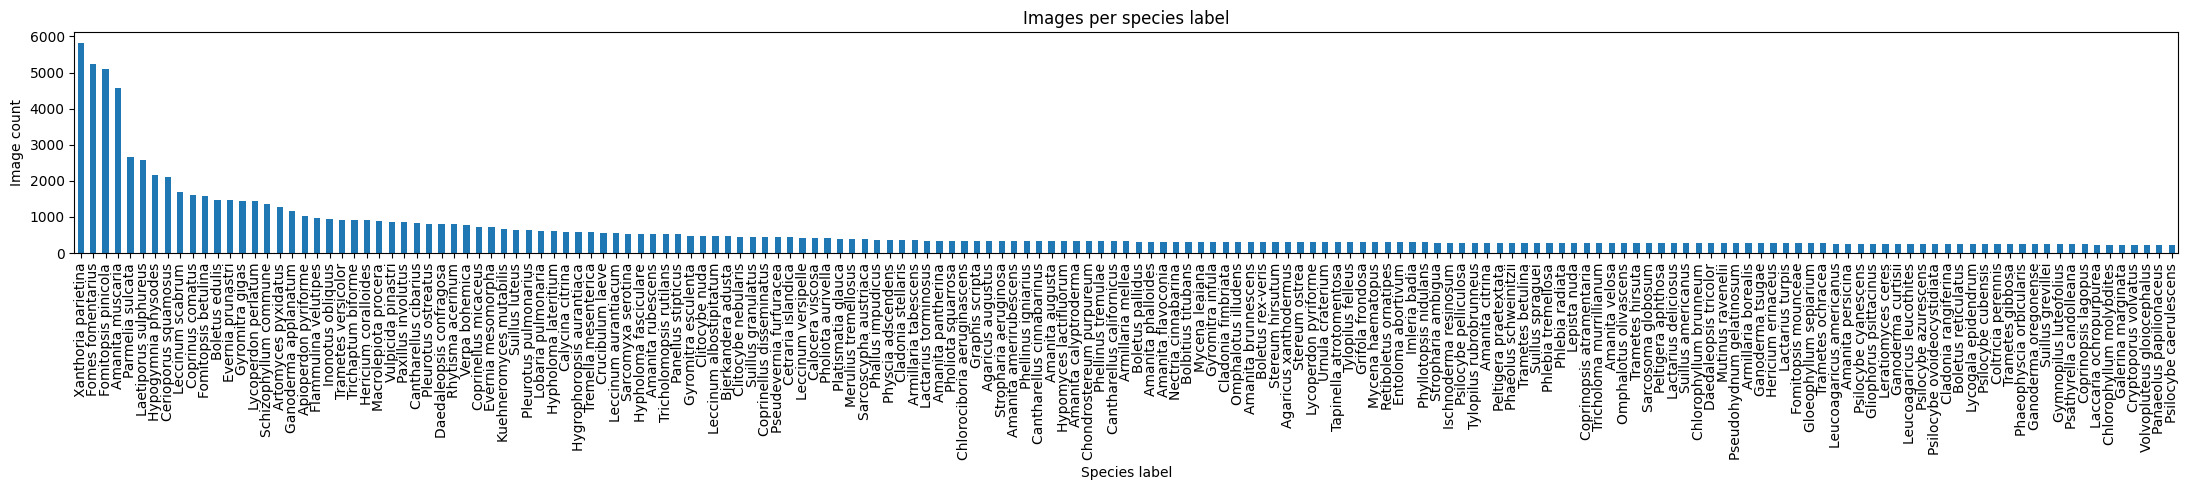

In [33]:
# species counts
species_plot_counts = df["folder"].value_counts()

# plot image count per species label
species_plot_counts.plot(
    kind="bar",
    figsize=(22, 5),
    title="Images per species label"
)

plt.xlabel("Species label")
plt.ylabel("Image count")
plt.tight_layout()
plt.show()

## Image size checks

In [52]:
size_metric_summary = (
    df[["width", "height", "aspect_ratio"]]
    .agg(["min", "max", "median", "mean", "std"])
)

size_metric_summary.loc["mode"] = (
    df[["width", "height", "aspect_ratio"]]
    .mode()
    .iloc[0]
)

size_metric_summary = size_metric_summary.loc[
    ["min", "max", "median", "mean", "mode", "std"]
]

size_metric_summary

,width,height,aspect_ratio
min,97.000000,109.000000,0.252000
max,500.000000,500.000000,4.385965
median,500.000000,375.000000,1.333333
mean,444.051159,420.094363,1.119261
mode,500.000000,500.000000,1.333333
std,72.997172,74.934771,0.358104


In [53]:
size_combinations = (
    df.groupby(["width", "height", "aspect_ratio"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

size_combinations["percent_total"] = (
    size_combinations["image_count"] / len(df) * 100
)

size_combinations["cumulative_percent"] = (
    size_combinations["percent_total"].cumsum()
)

size_combinations

,width,height,aspect_ratio,image_count,percent_total,cumulative_percent
0,500,375,1.333333,31293,30.064273,30.064273
1,375,500,0.750000,28265,27.155168,57.219441
2,500,333,1.501502,9220,8.857975,66.077416
3,281,500,0.562000,3529,3.390433,69.467849
4,500,281,1.779359,2548,2.447952,71.915801
...,...,...,...,...,...,...
743,449,420,1.069048,1,0.000961,99.996157
744,448,375,1.194667,1,0.000961,99.997118
745,442,444,0.995495,1,0.000961,99.998079
746,442,327,1.351682,1,0.000961,99.999039


In [ ]:
species_size_combinations = (
    df.groupby(["folder", "width", "height", "aspect_ratio"])
    .size()
    .reset_index(name="image_count")
    .sort_values(["folder", "image_count"], ascending=[True, False])
    .reset_index(drop=True)
)

species_size_combinations

,folder,width,height,aspect_ratio,image_count
0,Agaricus augustus,500,375,1.333333,255
1,Agaricus augustus,375,500,0.750000,37
2,Agaricus augustus,500,281,1.779359,9
3,Agaricus augustus,500,332,1.506024,4
4,Agaricus augustus,500,373,1.340483,4
...,...,...,...,...,...
13835,Xanthoria parietina,500,484,1.033058,1
13836,Xanthoria parietina,500,485,1.030928,1
13837,Xanthoria parietina,500,489,1.022495,1
13838,Xanthoria parietina,500,496,1.008065,1


In [ ]:
genus_size_combinations = (
    df.groupby(["genus", "width", "height", "aspect_ratio"])
    .size()
    .reset_index(name="image_count")
    .sort_values(["genus", "image_count"], ascending=[True, False])
    .reset_index(drop=True)
)

genus_size_combinations

,genus,width,height,aspect_ratio,image_count
0,Agaricus,500,375,1.333333,456
1,Agaricus,375,500,0.750000,77
2,Agaricus,500,281,1.779359,18
3,Agaricus,500,333,1.501502,16
4,Agaricus,281,500,0.562000,4
...,...,...,...,...,...
11781,Xanthoria,500,484,1.033058,1
11782,Xanthoria,500,485,1.030928,1
11783,Xanthoria,500,489,1.022495,1
11784,Xanthoria,500,496,1.008065,1


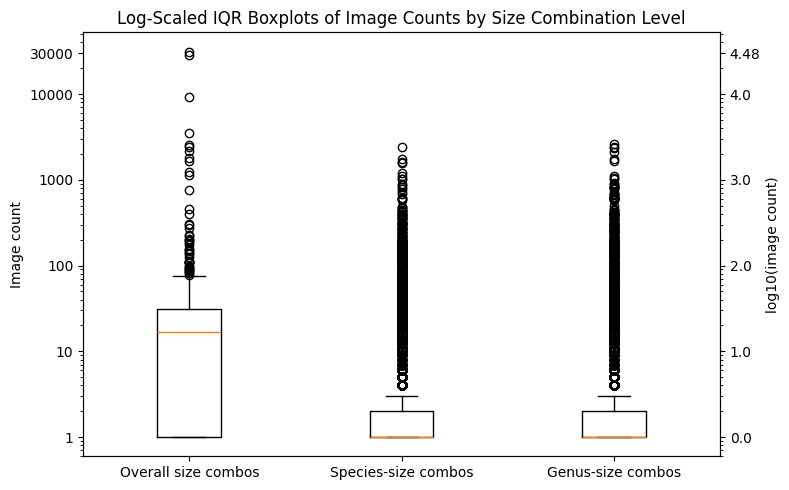

In [63]:
tick_values = [1, 10, 100, 1000, 10000, 30000]

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [
        size_combinations["image_count"],
        species_size_combinations["image_count"],
        genus_size_combinations["image_count"]
    ],
    tick_labels=[
        "Overall size combos",
        "Species-size combos",
        "Genus-size combos"
    ],
    whis=1.5
)

ax.set_yscale("log")
ax.set_yticks(tick_values)
ax.set_yticklabels([str(x) for x in tick_values])
ax.set_ylabel("Image count")

ax_right = ax.twinx()
ax_right.set_yscale("log")
ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(tick_values)
ax_right.set_yticklabels([round(math.log10(x), 2) for x in tick_values])
ax_right.set_ylabel("log10(image count)")

ax.set_title("Log-Scaled IQR Boxplots of Image Counts by Size Combination Level")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

- Original images vary in size, PyTorch will need to handle resizing during loading

---

## Visual Checks
This section looks directly at images to confirm EDA findings before moving on

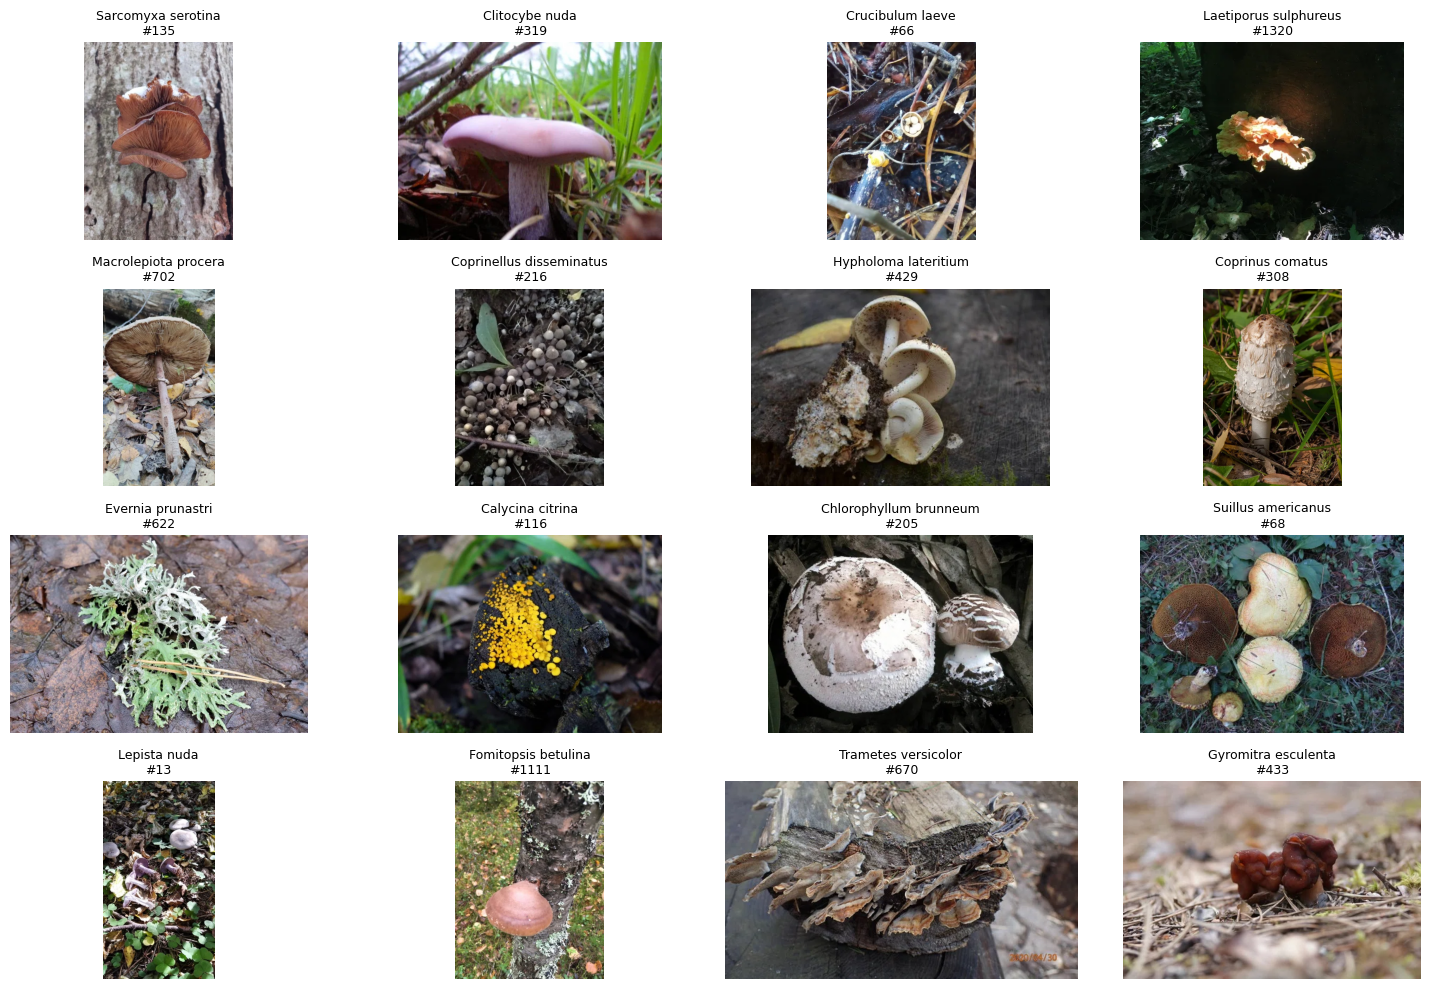

In [54]:
sample_images = df.sample(n=16, random_state=SEED)

fig, axes = plt.subplots(4, 4, figsize=(15, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_images.iterrows()):
    img = Image.open(row["file_path"])
    ax.imshow(img)
    ax.set_title(f"{row['folder']}\n#{row['img_number']}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

---

#### Early modeling decision:
Images will contain backgrounds for model to learn since mushrooms grow in different climates and different substrates (different trees, grassy, mulch, etc.)

---